---
title: Math puzzles
short_title: The Monty Hall Problem
subtitle: The Monty Hall Problem

numbering:
  headings: false

numbered_references: false
---

This chapter will help you think about programming from a math perspective, focusing on probability theory. To solve the exercises in this section you will need to have some basic understanding of:

- numpy arrays, lists or sets (there are multiple ways of solving this exercise)
- loops and if statements
- functions


# "Ask Marilyn"
The Monty Hall problem, is a probability problem originally based on a television show called "Let's make a deal", originally hosted by Monty Hall, who give the name to the problem. The problem was later popularized by the US american writer Marilyn vos Savant, who held a weekly column called "Ask Marilyn", answering puzzles and general philosophical questions. She is known by her important contributions in the fields of education and communications {cite:p}`MontyHall`.

Here is the problem received by Marilyn {cite:p}`AskMarilyn`:

> Suppose you’re on a game show, and you’re given the choice of three doors. Behind one door is a car, behind the others, goats. You pick a door, say #1, and the host, who knows what’s behind the doors, opens another door, say #3, which has a goat. They say to you, "Do you want to pick door #2?" Is it to your advantage to switch your choice of doors?

Try to work out (even intuitively) the probabilities of winning if you decide to change the door before doing the next section.

# Problem

Write a function that computes, nummerically, the probability of winning when changing the door. For instance, the function `monty_hall()` should receive an integer `n_doors`, representing the number of doors in the problem (in our case, 3), and an integer `n_sim`, representing the number of times the game will be simulated to compute the probability.

For example, if in 1 out of 10 simulations switching the door wins the game, that is a probability o 1/10. 


In [ ]:
def monty_hall(n_doors, n_sim):
    # Your code goes here

    return

In [71]:
import numpy as np
import random

def monty_hall(n_doors, n_sim):
    # Your code goes here
    count = 0

    doors = np.zeros((n_sim, n_doors))
    choices = np.zeros((n_sim, 1))
    for i in range(n_sim):
        idoor = random.randint(0,n_doors-1)
        doors[i, idoor] = 1

    for i in range(n_sim):
        possible_choices = np.arange(n_doors).tolist()
        ichoice = random.randint(0,n_doors-1)

        # defining the door the host will open
        possible_choices.remove(ichoice)
        doors_to_open = np.where(doors[i, possible_choices] == 0)[0].tolist()
        iopen = possible_choices[doors_to_open[random.randint(0,len(doors_to_open)-1)]]

        # defining the door we are going to switch to
        possible_choices.remove(iopen)
        iswitch = possible_choices[random.randint(0,len(possible_choices)-1)]
        choices[i,0] = doors[i, iswitch]
        if choices[i, 0]==1:
            count+=1

    return count/n_sim, choices, doors

p, choices, doors = monty_hall(3,1000)
print(p)

0.656


::::{dropdown} Solution
:::{code-cell} python
:tags: [skip-execution]
import numpy as np
import random

def monty_hall(n_doors, n_sim):
    # Your code goes here
    count = 0

    doors = np.zeros((n_sim, n_doors))
    choices = np.zeros((n_sim, 1))
    for i in range(n_sim):
        idoor = random.randint(0,n_doors-1)
        doors[i, idoor] = 1

    for i in range(n_sim):
        possible_choices = np.arange(n_doors).tolist()
        ichoice = random.randint(0,n_doors-1)

        # defining the door the host will open
        possible_choices.remove(ichoice)
        doors_to_open = np.where(doors[i, possible_choices] == 0)[0].tolist()
        iopen = possible_choices[doors_to_open[random.randint(0,len(doors_to_open)-1)]]

        # defining the door we are going to switch to
        possible_choices.remove(iopen)
        iswitch = possible_choices[random.randint(0,len(possible_choices)-1)]
        choices[i,0] = doors[i, iswitch]
        if choices[i, 0]==1:
            count+=1

    return count/n_sim, choices, doors

p, choices, doors = monty_hall(3,1000)
print(p)
:::

Note that the above function also keeps track of each door configuration and final choice, which might not be present in your own function, since this was not needed.

We can now use our function to see how the probability of switching converges as we increase the amount of simulations. Look at the code and plot below.

:::{code-cell} python
import matplotlib.pyplot as plt

nsim = []
prob = []
for i in range(2,20,1):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)

for i in range(20,200,5):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)

for i in range(200,3000,50):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)
    

plt.plot(nsim,prob)
plt.xlabel('Number of simulations')
plt.ylabel('Estimated probability')
plt.ylim(0,1)
plt.show()
:::

![](#converging_p)

We can see the probability converging to something close to 0.66. In fact, the exact number is 2/3. Was that what you expected based on your intuition?

You can try to investigate problems with different conditions. What happens if there are 5 doors intead of 3? And what if there is a prize in two of them? 

See the section below to see the mathematical explanation for this number.

::::

::::{dropdown} Mathematical explanation

Marilyn's response to this problem in the 90s stirred a lot of pushback. After giving the correct answer (2/3), she received hundreds of letters, among which many were from math school teachers and university teachers from renowed universities, refuting her answer (she also had to fight with a lot of sexism). Even after re explaining her answer multiple times, some of them were still sure her answer was wrong.

This is so, because this problem have a very non-intuitive answer, which defy our own intuition (or biases!). Thankfully, Marilyn did an amazing job in explaining the correct answer in a way that most of her readers could understand. From elementary school kids, to MIT professors and researchers. She also proposed a set of experiments that could be done inside a classroom, and that were replicated throughout multiple schools nationally. An amazing example of popularization of math!

Here is an excert of the explanation she gave:

> When you first choose door #1 from three, there’s a 1/3 chance that the prize is behind that one and a 2/3 chance that it’s behind one of the others. But then the host steps in and gives you a clue. If the prize is behind #2, the host shows you #3, and if the prize is behind #3, the host shows you #2. So when you switch, you win if the prize is behind #2 or #3. You win either way! But if you don’t switch, you win only if the prize is behind door #1.
>
> -- Marilyn vos Savant {cite:p}`AskMarilyn`

The story of Marilyn and the Monty Hall problem is a great reminder of how we must keep an open and humble mind to unintuitive answers. At the same time, it exemplifies how biases (and sexim!) are present even among "highly educated" people, and in renowned institutions. A reminder for us to be attentive and combative to this also inside our circles. 
::::

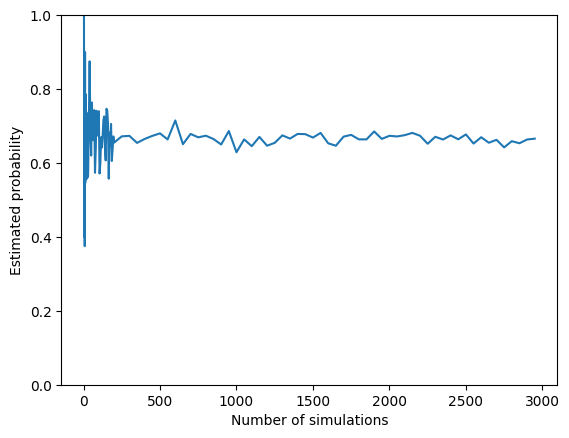

In [75]:
#| label = converging_p
import matplotlib.pyplot as plt

nsim = []
prob = []
for i in range(2,20,1):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)

for i in range(20,200,5):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)

for i in range(200,3000,50):
    p, _, _ = monty_hall(3,i)
    nsim.append(i)
    prob.append(p)
    

plt.plot(nsim,prob)
plt.xlabel('Number of simulations')
plt.ylabel('Estimated probability')
plt.ylim(0,1)
plt.show()